In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

1.	Read the CSV file using pandas. 
2.	Identify: 
o	missing values 
o	duplicate records 
o	invalid sales values 
3.	Replace missing Sales with mean. 
4.	Replace missing Profit with median. 
5.	Remove duplicate rows. 
6.	Convert OrderDate into datetime format. 
7.	Standardize City names into uppercase. 
8.	Detect outliers in Sales using IQR. 

In [3]:
df = pd.read_csv("retail.csv")
display(df)

,OrderID,CustomerName,Product,Category,City,Sales,Quantity,Discount,Profit,OrderDate,Feedback
0,1001,Asha,Keyboard,Electronics,Bangalore,1500.0,2,10,300.0,1/10/2024,Excellent product
1,1002,Ravi,Mouse,Electronics,Mysore,800.0,1,5,120.0,1/11/2024,Good quality
2,1003,Priya,Notebook,Stationery,Bangalore,200.0,5,0,50.0,1/12/2024,Very useful
3,1004,Kiran,Pen,Stationery,Mangalore,100.0,10,0,30.0,1/13/2024,Good
4,1005,Anu,Headphones,Electronics,Hubli,2500.0,1,15,400.0,1/14/2024,Sound is amazing
5,1006,Manoj,Chair,Furniture,Bangalore,3500.0,1,20,500.0,1/15/2024,Comfortable chair
6,1007,Sneha,Desk,Furniture,Mysore,4500.0,1,10,700.0,1/16/2024,Strong and durable
7,1008,Rahul,Laptop Stand,Electronics,Bangalore,1200.0,2,5,200.0,1/17/2024,Useful accessory
8,1009,Divya,Marker,Stationery,Hubli,150.0,6,0,40.0,1/18/2024,Good markers
9,1010,Vijay,Table,Furniture,Mangalore,5000.0,1,25,900.0,1/19/2024,Very sturdy


In [4]:
df['Sales'].fillna(df['Sales'].mean(), inplace=True)
df['Profit'].fillna(df['Profit'].median(), inplace=True)

/var/folders/n4/15gry_8x5zgdb5xxp5tx3d9c0000gn/T/ipykernel_500/819710723.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(df['Sales'].mean(), inplace=True)
/var/folders/n4/15gry_8x5zgdb5xxp5tx3d9c0000gn/T/ipykernel_500/819710723.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [5]:
# df['OrderDate'].astype('datetime')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [6]:
df['City'] = df['City'].apply(lambda x: x.upper())

In [17]:
q1 = df['Sales'].quantile(0.25)
q3 = df['Sales'].quantile(0.75)

iqr = q3-q1

high = q3 + 1.5*iqr
low = q1 - 1.5*iqr

df.loc[(df['Sales']<low) | (df['Sales']>high), 'Sales'] = df['Sales'].median()

1.	Create a bar chart showing total sales by category. 
2.	Create a line chart showing daily sales trend. 
3.	Create a pie chart showing city-wise order distribution. 
4.	Create a boxplot for Sales across categories. 
5.	Create a count plot for orders per city. 

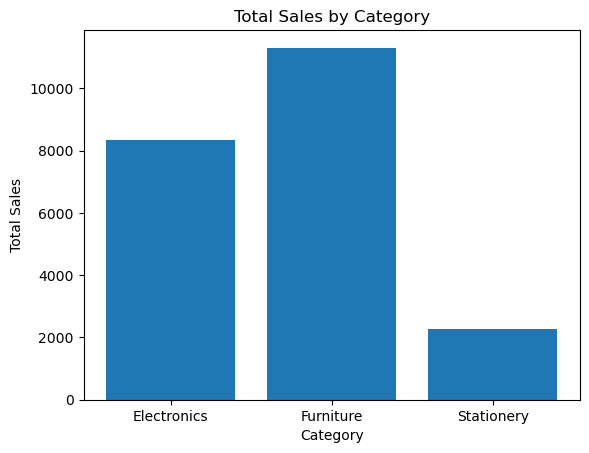

In [8]:
cat_counts = df[['Category', 'Sales']].groupby('Category').sum()

plt.bar(cat_counts.index, cat_counts['Sales'])
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Total Sales by Category')
plt.show()

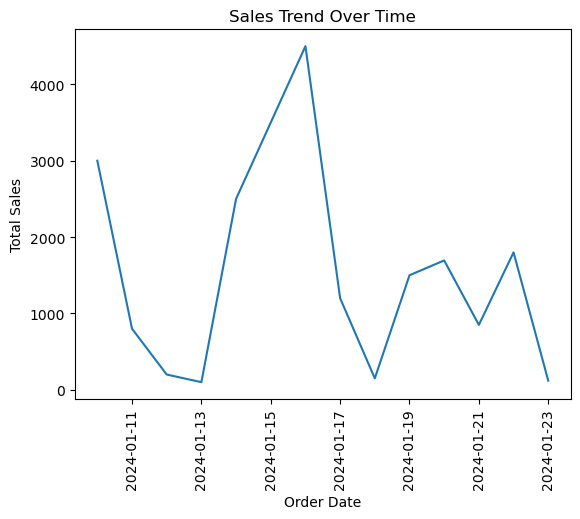

In [9]:
date_sales = df[['OrderDate', 'Sales']].groupby('OrderDate').sum()
plt.plot(date_sales.index, date_sales['Sales'])
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.title('Sales Trend Over Time')
plt.xticks(rotation=90)
plt.show()

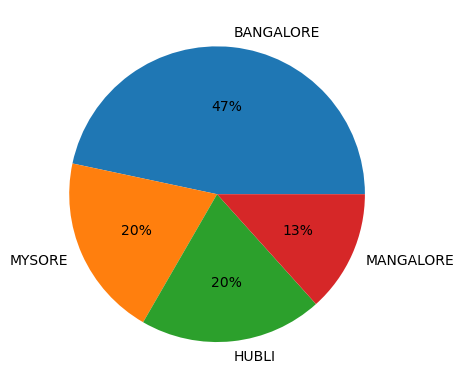

In [10]:
city_distribution = df['City'].value_counts()
plt.pie(city_distribution, labels=city_distribution.index, autopct='%.0f%%')
plt.show()

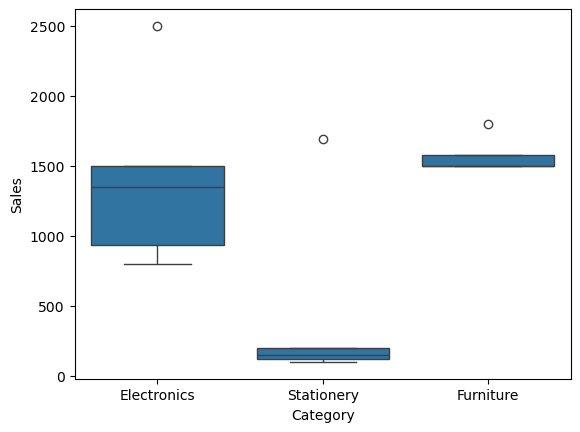

In [23]:
sns.boxplot(x=df['Category'], y=df['Sales'])
plt.show()

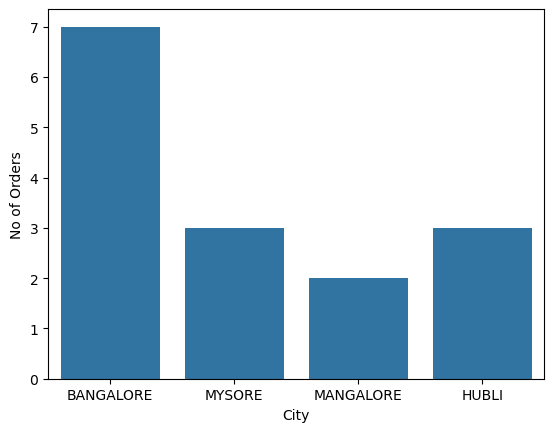

In [22]:
sns.countplot(df, x='City')
plt.ylabel('No of Orders')
plt.show()

3) Plotting using Matplotlib & Seaborn Exercise
   
Specified Questions

Create the following:
1. Histogram of Sales
2. Scatter plot: Sales vs Profit
3. Pair plot for numeric columns
4. Heatmap of correlations
5. Violin plot for category vs sales
6. KDE plot for Profit
   
This helps them compare:
- Matplotlib basics
- Seaborn advanced visual

<Axes: xlabel='Sales', ylabel='Count'>

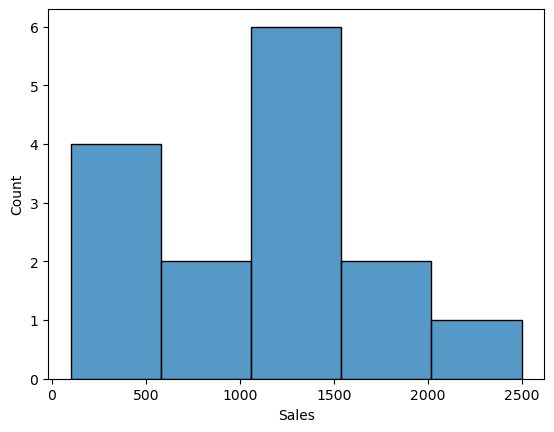

In [25]:
sns.histplot(df['Sales'])

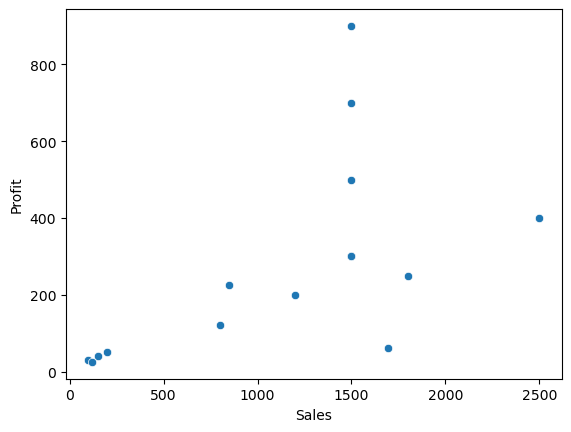

In [27]:
sns.scatterplot(df, x='Sales', y='Profit')
plt.show()

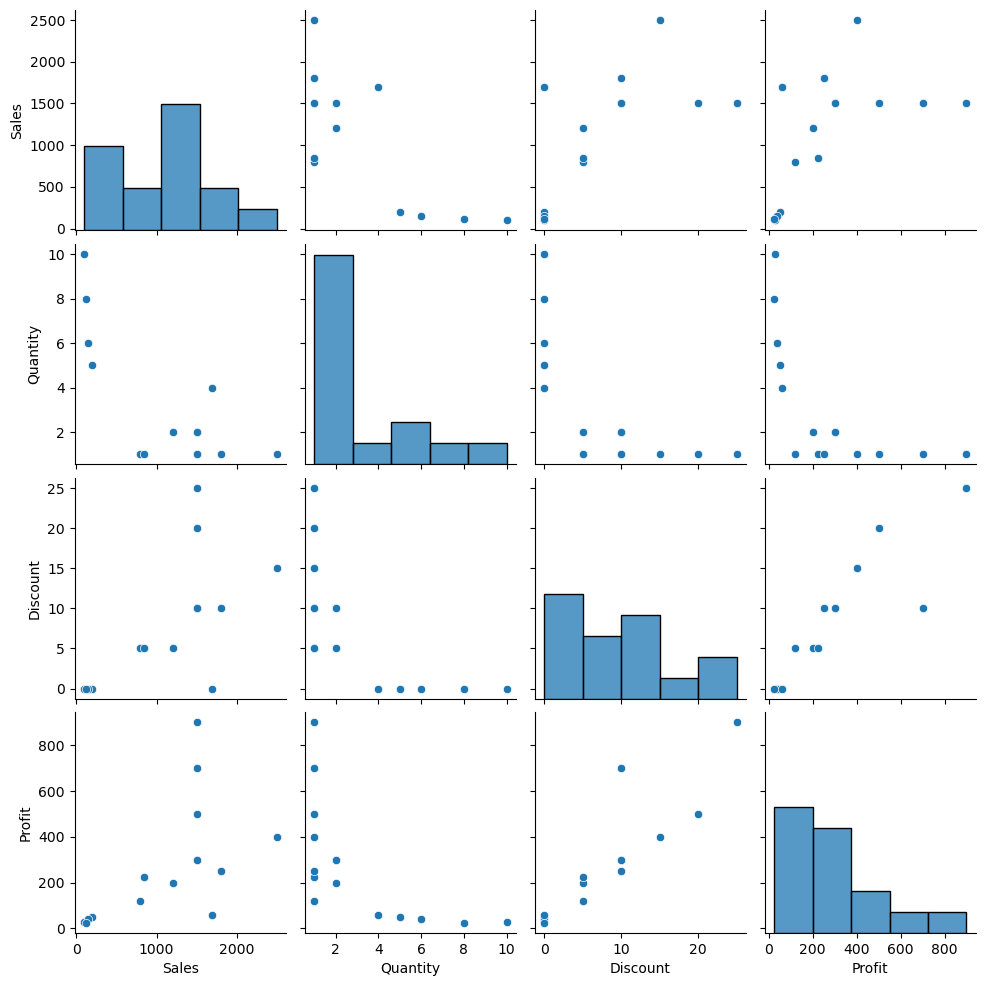

In [32]:
numeric_cols = df.loc[:, 'Sales':'Profit']
sns.pairplot(numeric_cols)
plt.show()

<Axes: >

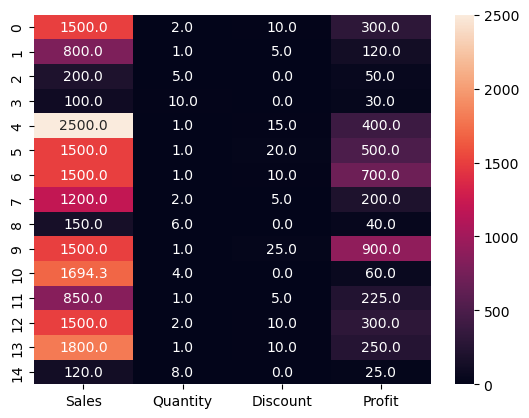

In [38]:
sns.heatmap(numeric_cols, annot=True, fmt='.1f')

<Axes: xlabel='Category', ylabel='Sales'>

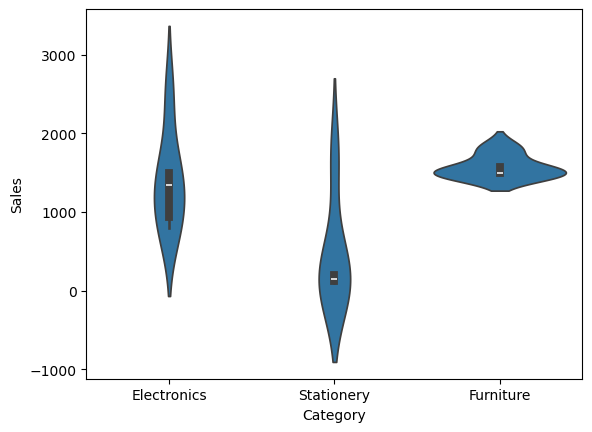

In [39]:
sns.violinplot(df, x='Category', y='Sales')

<Axes: xlabel='Profit', ylabel='Density'>

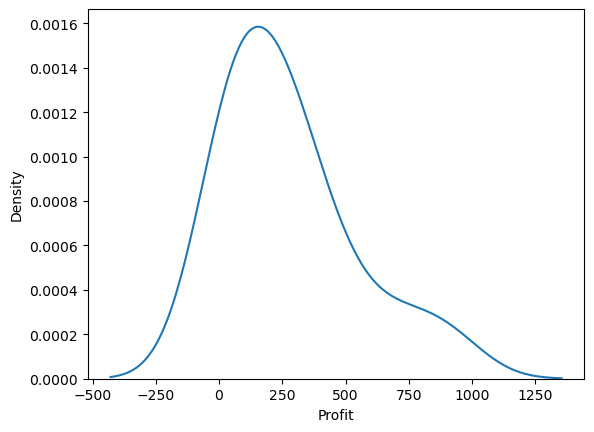

In [40]:
sns.kdeplot(df, x='Profit')

Data Aggregation and Group Operations Exercise

Specified Questions

1. Find total sales by category.
2. Find average profit by city.
3. Find top 3 selling products.
4. Group by category and calculate:
o total sales
o average discount
o max profit
5. Find city with highest total orders.
6. Perform multi-level grouping:
df.groupby(['City','Category'])['Sales'].sum()

In [43]:
df.groupby('Category')['Sales'].sum()

Category
Electronics    8350.000000
Furniture      6300.000000
Stationery     2264.285714
Name: Sales, dtype: float64

In [44]:
df.groupby('City')['Profit'].mean()

City
BANGALORE    205.000000
HUBLI        230.000000
MANGALORE    465.000000
MYSORE       348.333333
Name: Profit, dtype: float64

In [59]:
df.groupby('Product')['Sales'].sum().sort_values(ascending=False)[0:3]
# df.agg({'Product':'count'})

Product
Keyboard      3000.000000
Headphones    2500.000000
Notebook      1894.285714
Name: Sales, dtype: float64

In [68]:
cat_df = df.groupby('Category')
print("Total Sales\n", cat_df['Sales'].sum(),"\n")
print("Average Discount\n", cat_df['Discount'].mean(),"\n")
print("Max Profit\n", cat_df['Profit'].max(),"\n")


Total Sales
 Category
Electronics    8350.000000
Furniture      6300.000000
Stationery     2264.285714
Name: Sales, dtype: float64 

Average Discount
 Category
Electronics     8.333333
Furniture      16.250000
Stationery      0.000000
Name: Discount, dtype: float64 

Max Profit
 Category
Electronics    400.0
Furniture      900.0
Stationery      60.0
Name: Profit, dtype: float64 



In [74]:
df.groupby('City')['OrderID'].count().idxmax()

'BANGALORE'

In [75]:
df.groupby(['City','Category'])['Sales'].sum()

City       Category   
BANGALORE  Electronics    4200.000000
           Furniture      1500.000000
           Stationery     2014.285714
HUBLI      Electronics    2500.000000
           Furniture      1800.000000
           Stationery      150.000000
MANGALORE  Furniture      1500.000000
           Stationery      100.000000
MYSORE     Electronics    1650.000000
           Furniture      1500.000000
Name: Sales, dtype: float64

5) String Manipulation and Data Wrangling Exercise
   
Use CustomerName, Product, and Feedback.

Specified Questions
1. Convert customer names to uppercase.
2. Find length of each feedback message.
3. Extract first word from feedback.
4. Find rows where feedback contains "Good".
5. Replace "Excellent" with "Best".
6. Create a new column:
Product_Code = first 3 letters of Product + OrderID
7. Count frequency of words in feedback column.

In [81]:
df['CustomerName'] = df['CustomerName'].str.upper()

In [86]:
df['Feedback'].str.len()

0     17
1     12
2     11
3      4
4     16
5     17
6     18
7     16
8     12
9     11
10     6
11    12
12    17
13    11
14    12
Name: Feedback, dtype: int64

In [99]:
df['Feedback'].str.split().str[0]

0       Excellent
1            Good
2            Very
3            Good
4           Sound
5     Comfortable
6          Strong
7          Useful
8            Good
9            Very
10         Useful
11           Good
12      Excellent
13           Nice
14           Good
Name: Feedback, dtype: object

In [102]:
df['Feedback'].str.contains('Good')

0     False
1      True
2     False
3      True
4     False
5     False
6     False
7     False
8      True
9     False
10    False
11     True
12    False
13    False
14     True
Name: Feedback, dtype: bool

In [104]:
df['Feedback'] = df['Feedback'].str.replace("Excellent", "Best")

In [120]:
df['Product_Code'] = df['Product'].str.upper().str[:3] + df['OrderID'].astype(str)

In [127]:
df['Feedback'].str.split().str.len()

0     2
1     2
2     2
3     1
4     3
5     2
6     3
7     2
8     2
9     2
10    1
11    2
12    2
13    2
14    2
Name: Feedback, dtype: int64

In [121]:
display(df)

,OrderID,CustomerName,Product,Category,City,Sales,Quantity,Discount,Profit,OrderDate,Feedback,Code,Product_Code
0,1001,ASHA,Keyboard,Electronics,BANGALORE,1500.000000,2,10,300.0,2024-01-10,Best product,KEY1001,KEY1001
1,1002,RAVI,Mouse,Electronics,MYSORE,800.000000,1,5,120.0,2024-01-11,Good quality,MOU1002,MOU1002
2,1003,PRIYA,Notebook,Stationery,BANGALORE,200.000000,5,0,50.0,2024-01-12,Very useful,NOT1003,NOT1003
3,1004,KIRAN,Pen,Stationery,MANGALORE,100.000000,10,0,30.0,2024-01-13,Good,PEN1004,PEN1004
4,1005,ANU,Headphones,Electronics,HUBLI,2500.000000,1,15,400.0,2024-01-14,Sound is amazing,HEA1005,HEA1005
5,1006,MANOJ,Chair,Furniture,BANGALORE,1500.000000,1,20,500.0,2024-01-15,Comfortable chair,CHA1006,CHA1006
6,1007,SNEHA,Desk,Furniture,MYSORE,1500.000000,1,10,700.0,2024-01-16,Strong and durable,DES1007,DES1007
7,1008,RAHUL,Laptop Stand,Electronics,BANGALORE,1200.000000,2,5,200.0,2024-01-17,Useful accessory,LAP1008,LAP1008
8,1009,DIVYA,Marker,Stationery,HUBLI,150.000000,6,0,40.0,2024-01-18,Good markers,MAR1009,MAR1009
9,1010,VIJAY,Table,Furniture,MANGALORE,1500.000000,1,25,900.0,2024-01-19,Very sturdy,TAB1010,TAB1010
